# Machine Learning Safety – Exercise 4

## Model Testing and Validation

**Course:** Machine Learning Safety  
**University:** Otto von Guericke University Magdeburg

### Objective

This exercise focuses on testing and validating machine learning models used for autonomous driving perception.

Three binary CARLA classifiers are trained and evaluated:

1. Pedestrian detector
2. Traffic-light detector
3. Vehicle detector

The exercise investigates traditional software testing versus machine learning testing, distribution shift, ODD coverage, safety-constraint-based testing, and per-class model evaluation.

In [1]:
# ============================================================
# 1. Imports and Setup
# ============================================================

import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms

from PIL import Image

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Reproducibility
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Select GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

Using device: cuda


## 2. Dataset Setup

The CARLA dataset is used to train and evaluate binary classifiers for three perception tasks:

1. Pedestrian detection
2. Traffic-light detection
3. Vehicle detection

The same dataset structure is used for training, validation, and testing.

In [2]:
# ============================================================
# 3. Connect Google Drive
# ============================================================

from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Check that the CARLA dataset files are available

import os

train_zip = "/content/drive/MyDrive/ML_Safety/train.zip"
val_zip = "/content/drive/MyDrive/ML_Safety/validation.zip"
test_zip = "/content/drive/MyDrive/ML_Safety/test.zip"

print("Train ZIP exists:", os.path.exists(train_zip))
print("Validation ZIP exists:", os.path.exists(val_zip))
print("Test ZIP exists:", os.path.exists(test_zip))

Train ZIP exists: True
Validation ZIP exists: True
Test ZIP exists: True


In [4]:
# ============================================================
# 4. Extract CARLA Dataset
# ============================================================

import zipfile
import os

# Create directories for extracted datasets
base_dir = "/content/carla_data"

train_dir = os.path.join(base_dir, "train")
val_dir = os.path.join(base_dir, "validation")
test_dir = os.path.join(base_dir, "test")

os.makedirs(train_dir, exist_ok=True)
os.makedirs(val_dir, exist_ok=True)
os.makedirs(test_dir, exist_ok=True)

# Extract training dataset
with zipfile.ZipFile(train_zip, "r") as zip_ref:
    zip_ref.extractall(train_dir)

# Extract validation dataset
with zipfile.ZipFile(val_zip, "r") as zip_ref:
    zip_ref.extractall(val_dir)

# Extract test dataset
with zipfile.ZipFile(test_zip, "r") as zip_ref:
    zip_ref.extractall(test_dir)

print("Dataset extraction completed successfully.")
print("Train directory:", train_dir)
print("Validation directory:", val_dir)
print("Test directory:", test_dir)

Dataset extraction completed successfully.
Train directory: /content/carla_data/train
Validation directory: /content/carla_data/validation
Test directory: /content/carla_data/test


In [6]:
# ============================================================
# 5. Check Dataset Structure and File Counts
# ============================================================

def inspect_dataset(directory, name):
    print(f"\n{'=' * 60}")
    print(f"{name} DATASET")
    print(f"{'=' * 60}")

    # Show only the immediate contents
    items = sorted(os.listdir(directory))

    print("\nTop-level contents:")
    for item in items:
        item_path = os.path.join(directory, item)

        if os.path.isdir(item_path):
            print(f"📁 {item}/")
        else:
            print(f"📄 {item}")

    # Count files by extension
    file_counts = {}

    for root, dirs, files in os.walk(directory):
        for file in files:
            ext = os.path.splitext(file)[1].lower()

            if ext == "":
                ext = "[no extension]"

            file_counts[ext] = file_counts.get(ext, 0) + 1

    print("\nFile counts:")
    for ext, count in sorted(file_counts.items()):
        print(f"  {ext}: {count}")


inspect_dataset(train_dir, "TRAIN")
inspect_dataset(val_dir, "VALIDATION")
inspect_dataset(test_dir, "TEST")


TRAIN DATASET

Top-level contents:
📁 train/

File counts:
  .csv: 1
  .feather: 6
  .jpg: 7200
  .log: 2
  .png: 7200
  .yaml: 3

VALIDATION DATASET

Top-level contents:
📁 validation/

File counts:
  .csv: 1
  .feather: 6
  .jpg: 3600
  .log: 2
  .png: 3600
  .yaml: 3

TEST DATASET

Top-level contents:
📁 test/

File counts:
  .csv: 1
  .feather: 6
  .jpg: 3600
  .log: 2
  .png: 3600
  .yaml: 3


In [7]:
# ============================================================
# 6. Inspect Nested Dataset Structure
# ============================================================

print("TRAIN:")
print(os.listdir(train_dir))

print("\nVALIDATION:")
print(os.listdir(val_dir))

print("\nTEST:")
print(os.listdir(test_dir))

TRAIN:
['train']

VALIDATION:
['validation']

TEST:
['test']


In [8]:
# ============================================================
# 7. Inspect Dataset Classes
# ============================================================

print("TRAIN CLASSES:")
print(os.listdir(train_dir + "/train"))

print("\nVALIDATION CLASSES:")
print(os.listdir(val_dir + "/validation"))

print("\nTEST CLASSES:")
print(os.listdir(test_dir + "/test"))

TRAIN CLASSES:
['labels.feather', 'rgb-front', 'imu.feather', 'collisions.feather', 'carla.log', 'weather.feather', 'gnss.feather', 'labels.csv', 'sim.log', 'actions.feather', 'segmentation-front', '.hydra']

VALIDATION CLASSES:
['labels.feather', 'rgb-front', 'imu.feather', 'collisions.feather', 'carla.log', 'weather.feather', 'gnss.feather', 'labels.csv', 'sim.log', 'actions.feather', 'segmentation-front', '.hydra']

TEST CLASSES:
['labels.feather', 'rgb-front', 'imu.feather', 'collisions.feather', 'carla.log', 'weather.feather', 'gnss.feather', 'labels.csv', 'sim.log', 'actions.feather', 'segmentation-front', '.hydra']


In [9]:
# ============================================================
# 8. Inspect Labels
# ============================================================

import pandas as pd
import os

# Path to training labels
train_labels_path = os.path.join(train_dir, "train", "labels.csv")

# Load labels
train_labels = pd.read_csv(train_labels_path)

print("Training labels shape:", train_labels.shape)
print("\nColumn names:")
print(train_labels.columns.tolist())

print("\nFirst 5 rows:")
display(train_labels.head())

Training labels shape: (7200, 7)

Column names:
['frame', 'has_traffic_light', 'has_pedestrian', 'has_vehicle', 'px_traffic_light', 'px_pedestrian', 'px_vehicle']

First 5 rows:


,frame,has_traffic_light,has_pedestrian,has_vehicle,px_traffic_light,px_pedestrian,px_vehicle
0,0,False,False,True,0,0,85
1,10,False,True,True,14,301,1138
2,20,True,True,True,99,196,517
3,30,True,True,True,99,181,530
4,40,True,True,True,101,169,538


In [10]:
# ============================================================
# 9. Check Class Distribution
# ============================================================

target_columns = [
    "has_traffic_light",
    "has_pedestrian",
    "has_vehicle"
]

for target in target_columns:
    print("\n" + "=" * 60)
    print(f"CLASS DISTRIBUTION: {target}")
    print("=" * 60)

    counts = train_labels[target].value_counts()
    percentages = train_labels[target].value_counts(normalize=True) * 100

    distribution = pd.DataFrame({
        "Count": counts,
        "Percentage": percentages.round(2)
    })

    print(distribution)


CLASS DISTRIBUTION: has_traffic_light
                   Count  Percentage
has_traffic_light                   
True                5276       73.28
False               1924       26.72

CLASS DISTRIBUTION: has_pedestrian
                Count  Percentage
has_pedestrian                   
False            5482       76.14
True             1718       23.86

CLASS DISTRIBUTION: has_vehicle
             Count  Percentage
has_vehicle                   
True          5458       75.81
False         1742       24.19


In [11]:
# ============================================================
# 10. Verify Image and Label Correspondence
# ============================================================

import glob
import os

# RGB image directory
rgb_dir = os.path.join(train_dir, "train", "rgb-front")

# Get all PNG images
image_files = sorted(glob.glob(os.path.join(rgb_dir, "*.png")))

print("Number of RGB images:", len(image_files))
print("Number of label rows:", len(train_labels))

# Extract frame numbers from image filenames
image_frames = []

for image_path in image_files:
    filename = os.path.basename(image_path)
    frame_number = int(os.path.splitext(filename)[0])
    image_frames.append(frame_number)

# Compare frame IDs
label_frames = train_labels["frame"].tolist()

print("\nFirst 10 image frame IDs:")
print(image_frames[:10])

print("\nFirst 10 label frame IDs:")
print(label_frames[:10])

print("\nFrame IDs match:", image_frames == label_frames)

Number of RGB images: 0
Number of label rows: 7200

First 10 image frame IDs:
[]

First 10 label frame IDs:
[0, 10, 20, 30, 40, 50, 60, 70, 80, 90]

Frame IDs match: False


In [12]:
# ============================================================
# 11. Locate RGB Images
# ============================================================

import os

print("Searching for rgb-front folders...\n")

for root, dirs, files in os.walk("/content/carla_data/train"):
    if "rgb-front" in dirs:
        rgb_path = os.path.join(root, "rgb-front")
        print("RGB folder found:")
        print(rgb_path)

        # Show a few files
        rgb_files = sorted([
            f for f in os.listdir(rgb_path)
            if f.lower().endswith(".png")
        ])

        print("\nNumber of PNG images:", len(rgb_files))
        print("First 10 images:")
        print(rgb_files[:10])

Searching for rgb-front folders...

RGB folder found:
/content/carla_data/train/train/rgb-front

Number of PNG images: 0
First 10 images:
[]


In [13]:
# ============================================================
# 12. Find ALL RGB image files
# ============================================================

import os
import glob

print("Searching for image files...\n")

image_extensions = ["*.png", "*.jpg", "*.jpeg"]

for ext in image_extensions:
    files = glob.glob(
        "/content/carla_data/train/**/" + ext,
        recursive=True
    )

    print(f"{ext}: {len(files)} files")

    if files:
        print("First 10:")
        for f in files[:10]:
            print(f)

    print()

Searching for image files...

*.png: 7200 files
First 10:
/content/carla_data/train/train/segmentation-front/004510.png
/content/carla_data/train/train/segmentation-front/050340.png
/content/carla_data/train/train/segmentation-front/017310.png
/content/carla_data/train/train/segmentation-front/019390.png
/content/carla_data/train/train/segmentation-front/043110.png
/content/carla_data/train/train/segmentation-front/029250.png
/content/carla_data/train/train/segmentation-front/029830.png
/content/carla_data/train/train/segmentation-front/064450.png
/content/carla_data/train/train/segmentation-front/035780.png
/content/carla_data/train/train/segmentation-front/005190.png

*.jpg: 7200 files
First 10:
/content/carla_data/train/train/rgb-front/046440.jpg
/content/carla_data/train/train/rgb-front/030340.jpg
/content/carla_data/train/train/rgb-front/054350.jpg
/content/carla_data/train/train/rgb-front/071820.jpg
/content/carla_data/train/train/rgb-front/035940.jpg
/content/carla_data/train/tr

In [14]:
# ============================================================
# 12. Verify RGB Images and Label Frame IDs
# ============================================================

import os
import glob

# RGB image directory
rgb_dir = os.path.join(train_dir, "train", "rgb-front")

# Get JPG images
image_files = sorted(glob.glob(os.path.join(rgb_dir, "*.jpg")))

print("Number of RGB images:", len(image_files))
print("Number of label rows:", len(train_labels))

# Extract frame numbers from image filenames
image_frames = []

for image_path in image_files:
    filename = os.path.basename(image_path)
    frame_number = int(os.path.splitext(filename)[0])
    image_frames.append(frame_number)

# Frame IDs from labels
label_frames = train_labels["frame"].tolist()

print("\nFirst 10 image frame IDs:")
print(image_frames[:10])

print("\nFirst 10 label frame IDs:")
print(label_frames[:10])

# Check whether they match
print("\nFrame IDs match:", image_frames == label_frames)

Number of RGB images: 7200
Number of label rows: 7200

First 10 image frame IDs:
[0, 10, 20, 30, 40, 50, 60, 70, 80, 90]

First 10 label frame IDs:
[0, 10, 20, 30, 40, 50, 60, 70, 80, 90]

Frame IDs match: True


Image path:
/content/carla_data/train/train/rgb-front/000000.jpg

Image size:
(500, 500)

Corresponding labels:
frame                    0
has_traffic_light    False
has_pedestrian       False
has_vehicle           True
px_traffic_light         0
px_pedestrian            0
px_vehicle              85
Name: 0, dtype: object


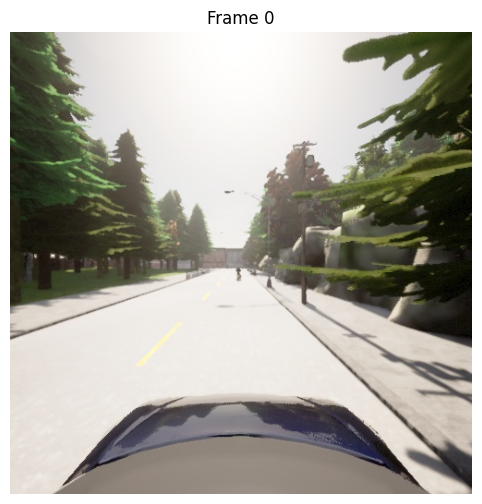

In [15]:
# ============================================================
# 13. Visualize Sample RGB Image and Its Labels
# ============================================================

import matplotlib.pyplot as plt
from PIL import Image

# Select first image
sample_image_path = image_files[0]

# Load image
sample_image = Image.open(sample_image_path)

# Get corresponding label row
sample_label = train_labels.iloc[0]

print("Image path:")
print(sample_image_path)

print("\nImage size:")
print(sample_image.size)

print("\nCorresponding labels:")
print(sample_label)

# Display image
plt.figure(figsize=(10, 6))
plt.imshow(sample_image)
plt.axis("off")
plt.title(f"Frame {sample_label['frame']}")
plt.show()

In [16]:
# ============================================================
# 14. Create Image-Label Dataset
# ============================================================

import pandas as pd
import os

# Create a copy of the labels
train_df = train_labels.copy()

# Create image path from frame number
train_df["image_path"] = train_df["frame"].apply(
    lambda x: os.path.join(
        rgb_dir,
        f"{int(x):06d}.jpg"
    )
)

# Check that all image paths exist
train_df["image_exists"] = train_df["image_path"].apply(os.path.exists)

print("Total samples:", len(train_df))
print("Images found:", train_df["image_exists"].sum())
print("Images missing:", (~train_df["image_exists"]).sum())

print("\nFirst 5 samples:")
display(train_df.head())

Total samples: 7200
Images found: 7200
Images missing: 0

First 5 samples:


,frame,has_traffic_light,has_pedestrian,has_vehicle,px_traffic_light,px_pedestrian,px_vehicle,image_path,image_exists
0,0,False,False,True,0,0,85,/content/carla_data/train/train/rgb-front/0000...,True
1,10,False,True,True,14,301,1138,/content/carla_data/train/train/rgb-front/0000...,True
2,20,True,True,True,99,196,517,/content/carla_data/train/train/rgb-front/0000...,True
3,30,True,True,True,99,181,530,/content/carla_data/train/train/rgb-front/0000...,True
4,40,True,True,True,101,169,538,/content/carla_data/train/train/rgb-front/0000...,True


In [17]:
# ============================================================
# 15. PyTorch Dataset Class
# ============================================================

class CARLADataset(Dataset):

    def __init__(self, dataframe, target_column, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.target_column = target_column
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):

        row = self.dataframe.iloc[index]

        # Load RGB image
        image = Image.open(row["image_path"]).convert("RGB")

        # Apply image transformations
        if self.transform:
            image = self.transform(image)

        # Convert Boolean label to integer
        label = int(row[self.target_column])

        return image, label

In [18]:
# ============================================================
# 16. Image Transformations
# ============================================================

image_size = 224

train_transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

eval_transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("Image transformations created successfully.")

Image transformations created successfully.


In [19]:
# ============================================================
# 17. Load Validation and Test Labels
# ============================================================

# Paths to validation and test label files
val_labels_path = os.path.join(
    val_dir, "validation", "labels.csv"
)

test_labels_path = os.path.join(
    test_dir, "test", "labels.csv"
)

# Load labels
val_labels = pd.read_csv(val_labels_path)
test_labels = pd.read_csv(test_labels_path)

print("Validation samples:", len(val_labels))
print("Test samples:", len(test_labels))

Validation samples: 3600
Test samples: 3600


In [20]:
# ============================================================
# 18. Create Validation and Test Image Paths
# ============================================================

# Validation RGB directory
val_rgb_dir = os.path.join(
    val_dir, "validation", "rgb-front"
)

# Test RGB directory
test_rgb_dir = os.path.join(
    test_dir, "test", "rgb-front"
)

# Create image paths
val_labels["image_path"] = val_labels["frame"].apply(
    lambda x: os.path.join(
        val_rgb_dir,
        f"{int(x):06d}.jpg"
    )
)

test_labels["image_path"] = test_labels["frame"].apply(
    lambda x: os.path.join(
        test_rgb_dir,
        f"{int(x):06d}.jpg"
    )
)

# Verify all images exist
val_images_exist = val_labels["image_path"].apply(os.path.exists)
test_images_exist = test_labels["image_path"].apply(os.path.exists)

print("Validation images found:", val_images_exist.sum())
print("Validation images missing:", (~val_images_exist).sum())

print("\nTest images found:", test_images_exist.sum())
print("Test images missing:", (~test_images_exist).sum())

Validation images found: 3600
Validation images missing: 0

Test images found: 3600
Test images missing: 0


In [21]:
# ============================================================
# 19. Create Datasets and DataLoaders
# ============================================================

# The three binary classification tasks
target_columns = {
    "pedestrian": "has_pedestrian",
    "traffic_light": "has_traffic_light",
    "vehicle": "has_vehicle"
}

# DataLoader settings
batch_size = 32
num_workers = 2

# Store datasets and loaders
datasets = {}
dataloaders = {}

for task_name, target_column in target_columns.items():

    print(f"\nCreating datasets for: {task_name}")

    # Training dataset
    train_dataset = CARLADataset(
        train_df,
        target_column=target_column,
        transform=train_transform
    )

    # Validation dataset
    val_dataset = CARLADataset(
        val_labels,
        target_column=target_column,
        transform=eval_transform
    )

    # Test dataset
    test_dataset = CARLADataset(
        test_labels,
        target_column=target_column,
        transform=eval_transform
    )

    # DataLoaders
    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=True
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True
    )

    datasets[task_name] = {
        "train": train_dataset,
        "validation": val_dataset,
        "test": test_dataset
    }

    dataloaders[task_name] = {
        "train": train_loader,
        "validation": val_loader,
        "test": test_loader
    }

    print("  Train samples:", len(train_dataset))
    print("  Validation samples:", len(val_dataset))
    print("  Test samples:", len(test_dataset))


Creating datasets for: pedestrian
  Train samples: 7200
  Validation samples: 3600
  Test samples: 3600

Creating datasets for: traffic_light
  Train samples: 7200
  Validation samples: 3600
  Test samples: 3600

Creating datasets for: vehicle
  Train samples: 7200
  Validation samples: 3600
  Test samples: 3600


In [22]:
# ============================================================
# 20. Verify One Training Batch
# ============================================================

for task_name in target_columns.keys():

    images, labels = next(iter(dataloaders[task_name]["train"]))

    print(f"\n{task_name.upper()}")
    print("-" * 40)
    print("Image batch shape:", images.shape)
    print("Label batch shape:", labels.shape)
    print("First 10 labels:", labels[:10].tolist())
    print("Unique labels:", torch.unique(labels).tolist())


PEDESTRIAN
----------------------------------------
Image batch shape: torch.Size([32, 3, 224, 224])
Label batch shape: torch.Size([32])
First 10 labels: [0, 1, 0, 0, 0, 1, 0, 0, 0, 0]
Unique labels: [0, 1]

TRAFFIC_LIGHT
----------------------------------------
Image batch shape: torch.Size([32, 3, 224, 224])
Label batch shape: torch.Size([32])
First 10 labels: [0, 1, 1, 1, 1, 1, 1, 1, 1, 1]
Unique labels: [0, 1]

VEHICLE
----------------------------------------
Image batch shape: torch.Size([32, 3, 224, 224])
Label batch shape: torch.Size([32])
First 10 labels: [1, 1, 1, 1, 0, 1, 1, 1, 1, 1]
Unique labels: [0, 1]


In [23]:
# ============================================================
# 21. Define ResNet-18 Binary Classifier
# ============================================================

def create_model():
    """
    Create a ResNet-18 model for binary classification.
    """

    model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

    # Replace the final classification layer
    num_features = model.fc.in_features
    model.fc = nn.Linear(num_features, 2)

    return model.to(device)


# Create one model for each perception task
models_dict = {
    "pedestrian": create_model(),
    "traffic_light": create_model(),
    "vehicle": create_model()
}

print("Three ResNet-18 models created successfully.")

for task_name, model in models_dict.items():
    print(f"{task_name}: {model.__class__.__name__}")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 166MB/s]


Three ResNet-18 models created successfully.
pedestrian: ResNet
traffic_light: ResNet
vehicle: ResNet


In [24]:
# ============================================================
# 22. Loss Function and Optimizers
# ============================================================

criterion = nn.CrossEntropyLoss()

optimizers = {
    "pedestrian": optim.Adam(
        models_dict["pedestrian"].parameters(),
        lr=1e-4
    ),

    "traffic_light": optim.Adam(
        models_dict["traffic_light"].parameters(),
        lr=1e-4
    ),

    "vehicle": optim.Adam(
        models_dict["vehicle"].parameters(),
        lr=1e-4
    )
}

print("Loss function and optimizers created successfully.")

Loss function and optimizers created successfully.


In [25]:
# ============================================================
# 23. Training and Validation Function
# ============================================================

def train_model(model, train_loader, val_loader, optimizer, criterion, epochs=3):
    """
    Train a model and evaluate it on the validation set after each epoch.
    """

    history = {
        "train_loss": [],
        "val_loss": [],
        "train_accuracy": [],
        "val_accuracy": []
    }

    for epoch in range(epochs):

        # ----------------------------------------------------
        # Training
        # ----------------------------------------------------
        model.train()

        running_loss = 0.0
        correct = 0
        total = 0

        for images, labels in train_loader:

            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)

            _, predictions = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predictions == labels).sum().item()

        train_loss = running_loss / total
        train_accuracy = correct / total

        # ----------------------------------------------------
        # Validation
        # ----------------------------------------------------
        model.eval()

        val_running_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():

            for images, labels in val_loader:

                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                val_running_loss += loss.item() * images.size(0)

                _, predictions = torch.max(outputs, 1)

                val_total += labels.size(0)
                val_correct += (predictions == labels).sum().item()

        val_loss = val_running_loss / val_total
        val_accuracy = val_correct / val_total

        # Store history
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_accuracy"].append(train_accuracy)
        history["val_accuracy"].append(val_accuracy)

        print(
            f"Epoch {epoch + 1}/{epochs} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_accuracy:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Acc: {val_accuracy:.4f}"
        )

    return history

In [26]:
# ============================================================
# 24. Train Pedestrian Classifier
# ============================================================

pedestrian_history = train_model(
    model=models_dict["pedestrian"],
    train_loader=dataloaders["pedestrian"]["train"],
    val_loader=dataloaders["pedestrian"]["validation"],
    optimizer=optimizers["pedestrian"],
    criterion=criterion,
    epochs=3
)

Epoch 1/3 | Train Loss: 0.4666 | Train Acc: 0.7925 | Val Loss: 0.6016 | Val Acc: 0.7356
Epoch 2/3 | Train Loss: 0.3511 | Train Acc: 0.8529 | Val Loss: 0.6275 | Val Acc: 0.7297
Epoch 3/3 | Train Loss: 0.2722 | Train Acc: 0.8844 | Val Loss: 0.6966 | Val Acc: 0.7542


In [27]:
# ============================================================
# 25. Train Traffic-Light Classifier
# ============================================================

traffic_light_history = train_model(
    model=models_dict["traffic_light"],
    train_loader=dataloaders["traffic_light"]["train"],
    val_loader=dataloaders["traffic_light"]["validation"],
    optimizer=optimizers["traffic_light"],
    criterion=criterion,
    epochs=3
)

Epoch 1/3 | Train Loss: 0.1634 | Train Acc: 0.9318 | Val Loss: 0.0940 | Val Acc: 0.9675
Epoch 2/3 | Train Loss: 0.0783 | Train Acc: 0.9714 | Val Loss: 0.0641 | Val Acc: 0.9783
Epoch 3/3 | Train Loss: 0.0483 | Train Acc: 0.9844 | Val Loss: 0.0855 | Val Acc: 0.9742


In [28]:
# ============================================================
# 26. Train Vehicle Classifier
# ============================================================

vehicle_history = train_model(
    model=models_dict["vehicle"],
    train_loader=dataloaders["vehicle"]["train"],
    val_loader=dataloaders["vehicle"]["validation"],
    optimizer=optimizers["vehicle"],
    criterion=criterion,
    epochs=3
)

Epoch 1/3 | Train Loss: 0.3218 | Train Acc: 0.8479 | Val Loss: 0.3302 | Val Acc: 0.8558
Epoch 2/3 | Train Loss: 0.2084 | Train Acc: 0.9093 | Val Loss: 0.2914 | Val Acc: 0.8742
Epoch 3/3 | Train Loss: 0.1685 | Train Acc: 0.9283 | Val Loss: 0.3070 | Val Acc: 0.8811


In [29]:
# ============================================================
# 27. Save Trained Models
# ============================================================

model_dir = "/content/carla_models"
os.makedirs(model_dir, exist_ok=True)

torch.save(
    models_dict["pedestrian"].state_dict(),
    os.path.join(model_dir, "pedestrian_resnet18.pth")
)

torch.save(
    models_dict["traffic_light"].state_dict(),
    os.path.join(model_dir, "traffic_light_resnet18.pth")
)

torch.save(
    models_dict["vehicle"].state_dict(),
    os.path.join(model_dir, "vehicle_resnet18.pth")
)

print("All three models saved successfully.")

for filename in sorted(os.listdir(model_dir)):
    filepath = os.path.join(model_dir, filename)
    size_mb = os.path.getsize(filepath) / (1024 ** 2)
    print(f"{filename}: {size_mb:.2f} MB")

All three models saved successfully.
pedestrian_resnet18.pth: 42.72 MB
traffic_light_resnet18.pth: 42.72 MB
vehicle_resnet18.pth: 42.72 MB


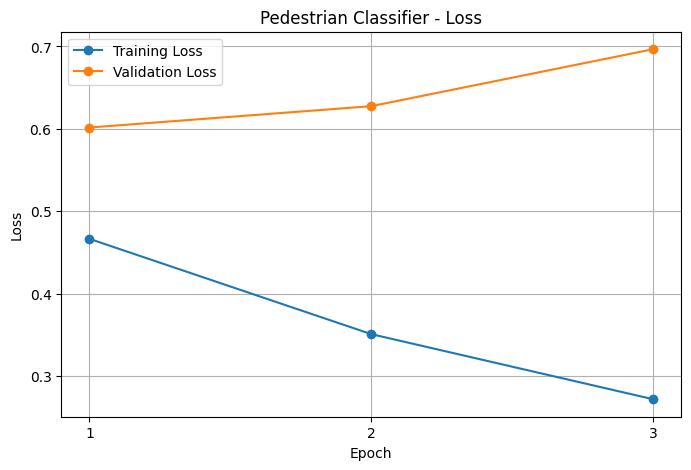

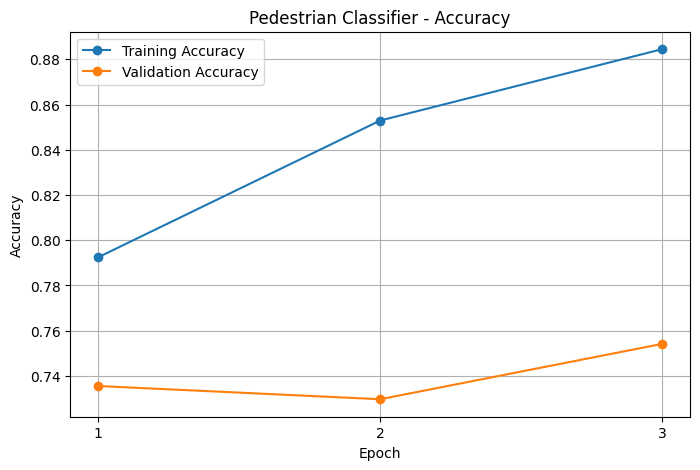

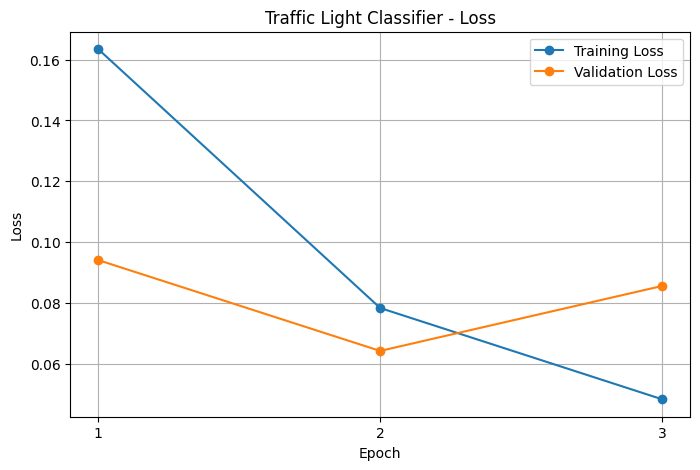

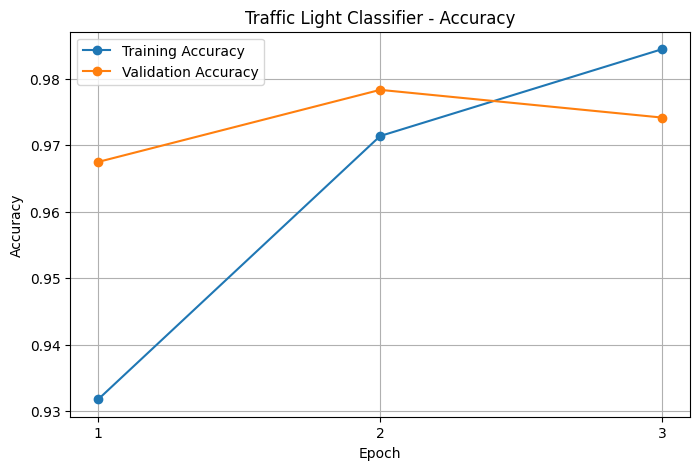

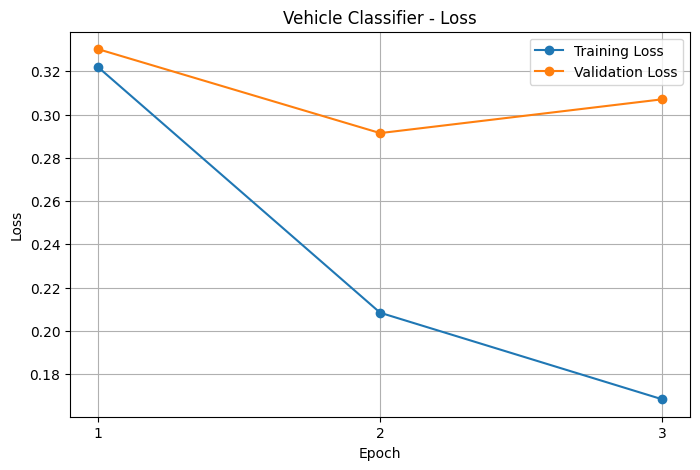

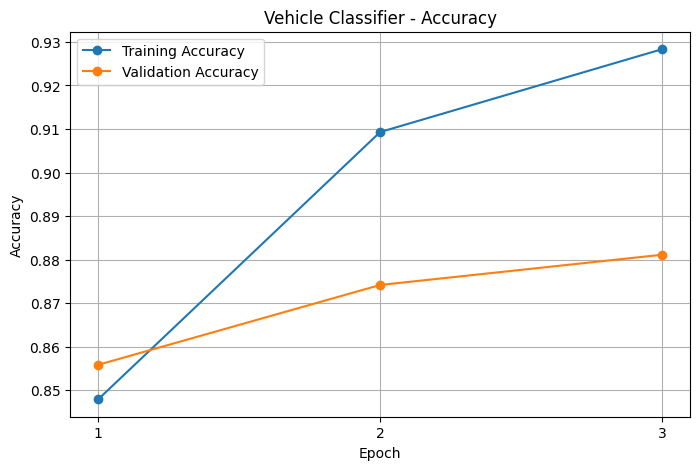

In [30]:
# ============================================================
# 28. Plot Training and Validation Performance
# ============================================================

histories = {
    "Pedestrian": pedestrian_history,
    "Traffic Light": traffic_light_history,
    "Vehicle": vehicle_history
}

for model_name, history in histories.items():

    epochs = range(1, len(history["train_loss"]) + 1)

    # Loss plot
    plt.figure(figsize=(8, 5))

    plt.plot(
        epochs,
        history["train_loss"],
        marker="o",
        label="Training Loss"
    )

    plt.plot(
        epochs,
        history["val_loss"],
        marker="o",
        label="Validation Loss"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{model_name} Classifier - Loss")
    plt.xticks(list(epochs))
    plt.legend()
    plt.grid(True)
    plt.show()

    # Accuracy plot
    plt.figure(figsize=(8, 5))

    plt.plot(
        epochs,
        history["train_accuracy"],
        marker="o",
        label="Training Accuracy"
    )

    plt.plot(
        epochs,
        history["val_accuracy"],
        marker="o",
        label="Validation Accuracy"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"{model_name} Classifier - Accuracy")
    plt.xticks(list(epochs))
    plt.legend()
    plt.grid(True)
    plt.show()

## 3. Training Results

The three ResNet-18 binary classifiers were trained for three epochs using the CARLA training dataset.

The training curves show the development of training and validation loss and accuracy across the three epochs.

The traffic-light classifier achieved the strongest validation performance. The vehicle classifier also showed consistent improvement in validation accuracy. The pedestrian classifier showed a larger difference between training and validation performance, indicating a greater potential for overfitting.

These observations motivate the detailed testing and validation performed in the remainder of this exercise.

## 4.1 Traditional Testing vs. Machine Learning Testing

Traditional software testing is mainly based on predefined rules and expected outputs. Test cases can often be designed manually, and the expected result is known in advance.

Machine learning systems are different because their behaviour is learned from data rather than being completely specified by explicit rules. Therefore, testing must consider not only whether the implementation works correctly, but also whether the training data, test data, model behaviour, and deployment conditions are appropriate.

For the CARLA perception models used in this exercise, traditional functional testing can check whether the implementation produces predictions in the expected format. However, ML-specific testing is also necessary to investigate issues such as:

- Distribution shift between training and deployment conditions
- Performance differences between classes
- False negatives for safety-critical objects
- ODD coverage
- Robustness under different environmental conditions
- Safety constraints derived from the hazard analysis

Therefore, testing the three classifiers requires both conventional software checks and ML-specific evaluation.

## 4.2 Test Oracle

A test oracle determines whether the output of a system is correct.

For the CARLA binary classifiers, the ground-truth labels in the dataset provide a direct test oracle. Each test image has a corresponding ground-truth value for pedestrian, traffic-light, and vehicle presence.

The model prediction can therefore be compared with the corresponding ground-truth label.

For example:

- Ground truth = 1 and prediction = 1 → True Positive
- Ground truth = 0 and prediction = 0 → True Negative
- Ground truth = 0 and prediction = 1 → False Positive
- Ground truth = 1 and prediction = 0 → False Negative

These comparisons form the basis for precision, recall, F1-score, and the confusion matrices used later in this exercise.

## 4.3 Empirical Risk Minimization and Evaluation Metrics

The models are trained by minimizing a loss function over the available training data. In this exercise, cross-entropy loss is used for the binary classification tasks.

The final model evaluation should not rely on accuracy alone because the three datasets have different class distributions.

Therefore, the following metrics are considered:

- Accuracy
- Precision
- Recall
- F1-score

Recall is particularly important for safety-critical perception because a false negative can mean that an object that is actually present is not detected.

For the pedestrian classifier, for example, low recall would indicate that some pedestrian-containing scenes are incorrectly classified as scenes without pedestrians.

## 4.4 Distribution Shift

Distribution shift occurs when the data distribution encountered during evaluation or deployment differs from the distribution used during training.

For autonomous-driving perception systems, this can occur because of changes in environmental conditions such as weather, lighting, road appearance, or traffic situations.

The CARLA dataset contains different environmental conditions, so evaluating the trained models on unseen test data helps determine whether their performance generalizes beyond the training data.

In this exercise, the test set is kept separate from training and validation. The trained models are evaluated on the test set to measure their generalization performance.

In [31]:
# ============================================================
# 29. Evaluate Models on Test Set
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

def evaluate_model(model, test_loader):
    """
    Evaluate a trained binary classifier on the test set.
    """

    model.eval()

    all_predictions = []
    all_labels = []

    with torch.no_grad():

        for images, labels in test_loader:

            images = images.to(device)

            outputs = model(images)
            predictions = torch.argmax(outputs, dim=1)

            all_predictions.extend(predictions.cpu().numpy())
            all_labels.extend(labels.numpy())

    accuracy = accuracy_score(all_labels, all_predictions)
    precision = precision_score(
        all_labels,
        all_predictions,
        zero_division=0
    )
    recall = recall_score(
        all_labels,
        all_predictions,
        zero_division=0
    )
    f1 = f1_score(
        all_labels,
        all_predictions,
        zero_division=0
    )

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "labels": all_labels,
        "predictions": all_predictions
    }


# Evaluate all three classifiers
test_results = {}

for task_name in target_columns.keys():

    print(f"\nEvaluating {task_name} classifier...")

    test_results[task_name] = evaluate_model(
        models_dict[task_name],
        dataloaders[task_name]["test"]
    )

    result = test_results[task_name]

    print(f"Accuracy : {result['accuracy']:.4f}")
    print(f"Precision: {result['precision']:.4f}")
    print(f"Recall   : {result['recall']:.4f}")
    print(f"F1-score : {result['f1']:.4f}")


Evaluating pedestrian classifier...
Accuracy : 0.7539
Precision: 0.3834
Recall   : 0.4193
F1-score : 0.4005

Evaluating traffic_light classifier...
Accuracy : 0.9431
Precision: 0.9420
Recall   : 0.9810
F1-score : 0.9611

Evaluating vehicle classifier...
Accuracy : 0.8750
Precision: 0.9287
Recall   : 0.9026
F1-score : 0.9155


## 4.4 Test Set Evaluation Results

The trained classifiers were evaluated on the separate test dataset using accuracy, precision, recall, and F1-score.

| Classifier | Accuracy | Precision | Recall | F1-score |
|------------|----------|-----------|--------|----------|
| Pedestrian | 75.39% | 38.34% | 41.93% | 40.05% |
| Traffic Light | 94.31% | 94.20% | 98.10% | 96.11% |
| Vehicle | 87.50% | 92.87% | 90.26% | 91.55% |

The traffic-light classifier achieved the strongest overall performance, with an F1-score of 96.11% and recall of 98.10%. The vehicle classifier also performed well, achieving an F1-score of 91.55%.

The pedestrian classifier performed substantially worse, with a precision of 38.34%, recall of 41.93%, and F1-score of 40.05%. This indicates that pedestrian detection is considerably more challenging for the trained model.

The difference in performance between the classifiers demonstrates that model quality should be evaluated separately for each perception task rather than relying only on overall accuracy.

## 4.4 Distribution Shift Types

### Scenario 1: Winter conditions, wet roads and glare

**Distribution shift:** Covariate shift

**Justification:** The input distribution changes because the camera images now contain wet roads, different lighting conditions and glare. The underlying relationship between the scene and the correct perception output is assumed to remain the same.

**Expected effect on model performance:** Model performance may decrease because the visual appearance of the input data differs from the sunny daytime data used during training.

**Mitigation:** Add representative winter, wet-road and glare conditions to the training data and retrain or fine-tune the model.

---

### Scenario 2: A new zone with 60% cyclists

**Distribution shift:** Label shift

**Justification:** The class distribution changes. Cyclists were rare in the original training data (<5%), but represent 60% of road users in the new test zone. Therefore, the distribution of labels has changed.

**Expected effect on model performance:** Performance may decrease because the model was trained with a very different class distribution and may not be sufficiently prepared for the new prevalence of cyclists.

**Mitigation:** Include data representing the new class distribution and retrain or recalibrate the model.

---

### Scenario 3: New slimmer traffic-light design

**Distribution shift:** Concept shift

**Justification:** The appearance of the traffic lights has changed to a design that the model has never seen. The relationship between the input appearance and the target concept may therefore differ from what was learned during training.

**Expected effect on model performance:** The model may fail to recognize the new traffic-light design, resulting in increased classification errors.

**Mitigation:** Collect labelled examples of the new traffic-light design and retrain or fine-tune the model.

## 4.5 ODD Coverage with k-Projection Coverage

### What is k-Projection Coverage?

k-projection coverage measures how well a test set covers combinations of ODD (Operational Design Domain) features.

For k = 1, the coverage considers individual ODD features.

For k = 2, it considers combinations of two features.

For k = 3, it considers combinations of three features.

This is useful because a test set may contain many individual conditions while still missing important combinations of conditions. For example, a test set might contain both night conditions and rain conditions individually, but contain very few or no examples of the combination of night and rain.

Therefore, increasing k allows us to assess increasingly complex combinations of ODD conditions and helps identify gaps in the test set.

In [32]:
# ============================================================
# 31. Download ODD Coverage Implementation
# ============================================================

!git clone https://github.com/kkirchheim/odd-coverage.git

Cloning into 'odd-coverage'...
remote: Enumerating objects: 30, done.
remote: Counting objects: 100% (30/30), done.
remote: Compressing objects: 100% (30/30), done.
remote: Total 30 (delta 9), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (30/30), 12.82 KiB | 570.00 KiB/s, done.
Resolving deltas: 100% (9/9), done.


In [33]:
# ============================================================
# 32. Inspect ODD Coverage Repository
# ============================================================

!find /content/odd-coverage -maxdepth 2 -type f | sort

/content/odd-coverage/.git/config
/content/odd-coverage/.git/description
/content/odd-coverage/.git/HEAD
/content/odd-coverage/.git/index
/content/odd-coverage/.git/packed-refs
/content/odd-coverage/kprojection.py
/content/odd-coverage/LICENSE
/content/odd-coverage/README.md


In [34]:
# ============================================================
# 33. Read ODD Coverage Instructions
# ============================================================

!cat /content/odd-coverage/README.md

# Quantitative Projection Coverage 

Implementation of Quantitative Projection Coverage from the paper "Quantitative Projection Coverage for Testing ML-enabled Autonomous Systems" by Chih-Hong Cheng _et al._ available at [arxiv](https://arxiv.org/abs/1805.04333).

## Usage 

```python
from kprojection import KProjectionCoverage

# Create an Operational Design Domain (ODD) description
# This is a dict with one entry per dimension, which maps each dimension to possible values 
description = {
    "weather": ["good", "bad", "ugly"],
    "temperature": [1, 2, 3, 4],
    "humidity": [0.1, 0.2, 0.3, 0.4, 0.5],
}

# Create the metric for some value of k-way coverage 
cov = KProjectionCoverage(k=2, desc=description)

# Add covered scenarios to the metric
# Each scenario assigns a value to each dimension in the ODD description 
cov.add_scenario({"weather": "bad", "temperature": 1, "humidity": 0.1})
cov.add_scenario({"weather": "ugly", "temperature": 2, "humidity": 0.1})
cov.add_scenario({"weath

In [35]:
# ============================================================
# 34. Inspect K-Projection Coverage Implementation
# ============================================================

!cat /content/odd-coverage/kprojection.py

from dataclasses import dataclass
from itertools import combinations, product
from typing import Any, Dict, Iterable, List, Optional, Tuple, TypeVar
from abc import ABC, abstractmethod
from typing import TypeVar

__all__ = ["KCoverageResult", "KProjectionCoverage"]

Self = TypeVar("Self")

class Metric(ABC):
    def __init__(self, *args, **kwargs) -> None:
        pass

    @abstractmethod
    def update(self: Self, *args, **kwargs) -> Self:
        """
        Add values to the metric
        """
        raise NotImplementedError

    @abstractmethod
    def compute(self, *args, **kwargs):
        """
        Compute the metric
        """
        raise NotImplementedError


class Projection:
    """
    A single projection
    """

    def __init__(self, n_values: List[int], names: Optional[List[str]] = None) -> None:
        """
        Holds a subspace with the cartesian product of some dimension and
        monitors coverage for this subspace.

        :param n_values: list with n

In [37]:
# Check which main variables are currently available

print([name for name in globals() if not name.startswith("_")])

['In', 'Out', 'get_ipython', 'exit', 'quit', 'os', 'random', 'np', 'pd', 'plt', 'torch', 'nn', 'optim', 'Dataset', 'DataLoader', 'models', 'transforms', 'Image', 'accuracy_score', 'precision_score', 'recall_score', 'f1_score', 'confusion_matrix', 'classification_report', 'SEED', 'device', 'drive', 'train_zip', 'val_zip', 'test_zip', 'zipfile', 'base_dir', 'train_dir', 'val_dir', 'test_dir', 'zip_ref', 'show_directory_structure', 'inspect_dataset', 'train_labels_path', 'train_labels', 'target_columns', 'target', 'counts', 'percentages', 'distribution', 'glob', 'rgb_dir', 'image_files', 'image_frames', 'label_frames', 'root', 'dirs', 'files', 'rgb_path', 'rgb_files', 'image_extensions', 'ext', 'f', 'image_path', 'filename', 'frame_number', 'sample_image_path', 'sample_image', 'sample_label', 'train_df', 'CARLADataset', 'image_size', 'train_transform', 'eval_transform', 'val_labels_path', 'test_labels_path', 'val_labels', 'test_labels', 'val_rgb_dir', 'test_rgb_dir', 'val_images_exist', '

In [38]:
# ============================================================
# 36. Inspect CARLA Training Metadata
# ============================================================

print("Columns available:")
print(train_df.columns.tolist())

print("\nShape:")
print(train_df.shape)

print("\nFirst 5 rows:")
display(train_df.head())

Columns available:
['frame', 'has_traffic_light', 'has_pedestrian', 'has_vehicle', 'px_traffic_light', 'px_pedestrian', 'px_vehicle', 'image_path', 'image_exists']

Shape:
(7200, 9)

First 5 rows:


,frame,has_traffic_light,has_pedestrian,has_vehicle,px_traffic_light,px_pedestrian,px_vehicle,image_path,image_exists
0,0,False,False,True,0,0,85,/content/carla_data/train/train/rgb-front/0000...,True
1,10,False,True,True,14,301,1138,/content/carla_data/train/train/rgb-front/0000...,True
2,20,True,True,True,99,196,517,/content/carla_data/train/train/rgb-front/0000...,True
3,30,True,True,True,99,181,530,/content/carla_data/train/train/rgb-front/0000...,True
4,40,True,True,True,101,169,538,/content/carla_data/train/train/rgb-front/0000...,True


## 4.5 ODD Coverage with k-Projection Coverage

The available CARLA metadata does not explicitly provide environmental ODD attributes such as weather, lighting, road surface, or traffic density. Therefore, the supplied k-projection implementation cannot be applied to those environmental dimensions using the available metadata.

For a reproducible demonstration using the available scenario metadata, three categorical dimensions are used:

- Traffic-light presence: present / absent
- Pedestrian presence: present / absent
- Vehicle presence: present / absent

These dimensions represent scene conditions available in the provided metadata. They are used to demonstrate the k-projection coverage calculation for k = 1, 2, and 3.

This should not be interpreted as complete ODD coverage, because important environmental dimensions are not represented in the available metadata.

In [39]:
# ============================================================
# 37. Define Scenario Description for k-Projection Coverage
# ============================================================

odd_description = {
    "traffic_light": [False, True],
    "pedestrian": [False, True],
    "vehicle": [False, True]
}

print("ODD dimensions:")
for dimension, values in odd_description.items():
    print(f"{dimension}: {values}")

ODD dimensions:
traffic_light: [False, True]
pedestrian: [False, True]
vehicle: [False, True]


In [42]:
# ============================================================
# 38. Prepare Test Scenarios for ODD Coverage
# ============================================================

# Rename the metadata columns so that they match
# the ODD description exactly.

test_scenarios = test_labels[
    ["has_traffic_light", "has_pedestrian", "has_vehicle"]
].copy()

test_scenarios = test_scenarios.rename(
    columns={
        "has_traffic_light": "traffic_light",
        "has_pedestrian": "pedestrian",
        "has_vehicle": "vehicle"
    }
)

# Convert each row into the dictionary format required
# by KProjectionCoverage.
scenarios = test_scenarios.to_dict(orient="records")

print("Number of test scenarios:", len(scenarios))
print("\nFirst 5 scenarios:")

for scenario in scenarios[:5]:
    print(scenario)

Number of test scenarios: 3600

First 5 scenarios:
{'traffic_light': False, 'pedestrian': False, 'vehicle': False}
{'traffic_light': True, 'pedestrian': False, 'vehicle': True}
{'traffic_light': True, 'pedestrian': False, 'vehicle': True}
{'traffic_light': True, 'pedestrian': False, 'vehicle': True}
{'traffic_light': True, 'pedestrian': False, 'vehicle': True}


In [43]:
# ============================================================
# 39. Calculate k-Projection Coverage
# ============================================================

import sys
sys.path.append("/content/odd-coverage")

from kprojection import KProjectionCoverage

coverage_results = {}

for k in [1, 2, 3]:

    coverage = KProjectionCoverage(
        k=k,
        desc=odd_description
    )

    coverage.add_scenarios(scenarios)

    result = coverage.compute()

    coverage_results[k] = result

    print(f"\nk = {k}")
    print("-" * 40)
    print(f"Coverage : {result.coverage:.4f} ({result.coverage * 100:.2f}%)")
    print(f"Covered  : {result.covered}")
    print(f"Total    : {result.total}")
    print(f"Scenarios: {result.scenes}")


k = 1
----------------------------------------
Coverage : 1.0000 (100.00%)
Covered  : 6
Total    : 6
Scenarios: 3600

k = 2
----------------------------------------
Coverage : 1.0000 (100.00%)
Covered  : 12
Total    : 12
Scenarios: 3600

k = 3
----------------------------------------
Coverage : 1.0000 (100.00%)
Covered  : 8
Total    : 8
Scenarios: 3600


### k-Projection Coverage Results

The supplied `odd-coverage` implementation was applied to the 3,600 test scenarios for k = 1, 2, and 3.

| k | Covered | Total | Coverage |
|---|---:|---:|---:|
| 1 | 6 | 6 | 100.00% |
| 2 | 12 | 12 | 100.00% |
| 3 | 8 | 8 | 100.00% |

The coverage remains at 100% as k increases from 1 to 3. This means that the test set contains every possible value combination for the three dimensions included in this analysis.

Therefore, with respect to these three dimensions, the test set provides complete k-projection coverage.

However, this result does not imply complete ODD coverage of the autonomous-driving system. The available metadata does not contain environmental dimensions such as weather, lighting, road condition, or traffic density. Consequently, the 100% coverage result only applies to the three available scenario dimensions: traffic-light presence, pedestrian presence, and vehicle presence.

Additional ODD dimensions would be required to assess broader scenario coverage.

## 4.6 Designing a Test Suite from Safety Constraints

The safety constraints identified in Exercise 2.7 are used to design model-level test cases.

The two model-level constraints are:

- SC-1: Pedestrian recall must remain above the required threshold.
- SC-2: Vehicle detection must be validated before braking.

Each constraint is linked to a concrete test input, an expected model behaviour, and a pass criterion.

### Safety-Constraint Test Suite

| Constraint ID | Constraint | Test Input Description | Expected Output | Pass Criterion |
|---|---|---|---|---|
| **SC-1** | Pedestrian recall must remain above threshold | Evaluate the pedestrian classifier on the held-out test set containing both pedestrian-present and pedestrian-absent scenes. Include challenging pedestrian scenes where available. | The pedestrian classifier should correctly identify scenes containing pedestrians. | Pedestrian recall must be at or above the safety threshold defined for the system. |
| **SC-2** | Vehicle detection validated before braking | Evaluate the vehicle classifier on the held-out test set containing scenes with and without vehicles. The vehicle detection result is used as evidence before a braking decision. | Vehicles present in the scene should be correctly detected, while vehicle-absent scenes should not incorrectly trigger vehicle detection. | Vehicle detection performance must satisfy the required evaluation threshold before the braking function is allowed to rely on the detection result. |